# HuBERT + BiLSTM

**Модель:** HuBERT-base + BiLSTM

In [26]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import time
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score as _f1, roc_auc_score
from transformers import HubertModel
import matplotlib.pyplot as plt

exp_dir = Path().resolve()
sys.path.insert(0, str(exp_dir.parent.parent))
sys.path.insert(0, str(exp_dir))

from shared import config, data_utils, train_utils
from shared.evaluate import find_optimal_threshold, evaluate
from shared.results_utils import save_result_csv

train_utils.set_seed(config.RANDOM_STATE)

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(DEVICE)

cpu


In [27]:
(
    paths_trainval, labels_trainval, letters_trainval,
    paths_test, labels_test, letters_test,
) = data_utils.get_test_split()

idx = np.arange(len(paths_trainval))
idx_tr, idx_val = train_test_split(
    idx, test_size=0.18, stratify=labels_trainval, random_state=config.RANDOM_STATE
)
paths_train, paths_val = paths_trainval[idx_tr], paths_trainval[idx_val]
labels_train, labels_val = labels_trainval[idx_tr], labels_trainval[idx_val]
letters_train, letters_val = letters_trainval[idx_tr], letters_trainval[idx_val]

print(f"Train: {len(paths_train)}, Val: {len(paths_val)}, Test: {len(paths_test)}")

Train: 1931, Val: 425, Test: 416


## Предвычисление эмбеддингов

In [28]:
SR = config.TARGET_SR
MAX_LEN = int(SR * config.MAX_DURATION_SEC)

hubert_encoder = HubertModel.from_pretrained("facebook/hubert-base-ls960").to(DEVICE)
hubert_encoder.eval()
ENCODER_DIM = hubert_encoder.config.hidden_size  # 768

def compute_hubert_embeddings(paths, batch_size=8):
    """Возвращает list[np.ndarray shape (T, 768)] — последовательности для каждого файла."""
    all_embeddings = []
    for i in range(0, len(paths), batch_size):
        batch_paths = paths[i:i+batch_size]
        wavs = []
        for p in batch_paths:
            y, _ = data_utils.load_audio(p, sr=SR)
            wavs.append(y)
        waves_tensor = torch.stack([
            torch.from_numpy(np.pad(w, (0, max(0, MAX_LEN - len(w))))[:MAX_LEN]).float()
            for w in wavs
        ]).to(DEVICE)
        with torch.no_grad():
            hidden = hubert_encoder(waves_tensor).last_hidden_state  # (B, T, 768)
        for h in hidden:
            all_embeddings.append(h.cpu().numpy())
        if (i // batch_size) % 20 == 0:
            print(f"  {i+len(batch_paths)}/{len(paths)}")
    return all_embeddings

print("Извлечение HuBERT эмбеддингов (train)...")
emb_train = compute_hubert_embeddings(paths_train)
print("Val...")
emb_val   = compute_hubert_embeddings(paths_val)
print("Test...")
emb_test  = compute_hubert_embeddings(paths_test)
print(f"Форма одного эмбеддинга: {emb_train[0].shape}")

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Извлечение HuBERT эмбеддингов (train)...
  8/1931
  168/1931
  328/1931
  488/1931
  648/1931
  808/1931
  968/1931
  1128/1931
  1288/1931
  1448/1931
  1608/1931
  1768/1931
  1928/1931
Val...
  8/425
  168/425
  328/425
Test...
  8/416
  168/416
  328/416
Форма одного эмбеддинга: (499, 768)


In [29]:
MAX_T = max(e.shape[0] for e in emb_train + emb_val + emb_test)

def pad_emb(emb_list, max_t):
    out = np.zeros((len(emb_list), max_t, ENCODER_DIM), dtype=np.float32)
    for i, e in enumerate(emb_list):
        T = min(e.shape[0], max_t)
        out[i, :T] = e[:T]
    return out

E_train = pad_emb(emb_train, MAX_T)
E_val   = pad_emb(emb_val,   MAX_T)
E_test  = pad_emb(emb_test,  MAX_T)
print(f"Тензоры: train={E_train.shape}, val={E_val.shape}, test={E_test.shape}")

Тензоры: train=(1931, 499, 768), val=(425, 499, 768), test=(416, 499, 768)


In [30]:
BATCH_SIZE = 32
train_ds = TensorDataset(
    torch.from_numpy(E_train), torch.from_numpy(letters_train), torch.from_numpy(labels_train)
)
val_ds = TensorDataset(
    torch.from_numpy(E_val), torch.from_numpy(letters_val), torch.from_numpy(labels_val)
)
test_ds = TensorDataset(
    torch.from_numpy(E_test), torch.from_numpy(letters_test), torch.from_numpy(labels_test)
)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

n_letters = letters_train.shape[1]
LSTM_HIDDEN = 128

class LSTMHead(nn.Module):
    def __init__(self, input_dim, lstm_hidden, n_letters, num_classes=2, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, lstm_hidden, batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(lstm_hidden * 2 + n_letters, num_classes)
        self.n_letters = n_letters

    def forward(self, x, letters=None):
        out, _ = self.lstm(x)
        agg = out.mean(dim=1)
        agg = self.dropout(agg)
        if self.n_letters > 0 and letters is not None:
            agg = torch.cat([agg, letters], dim=1)
        return self.fc(agg)

model = LSTMHead(ENCODER_DIM, LSTM_HIDDEN, n_letters).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f"Параметров головы: {n_params}")

Параметров головы: 920086


In [31]:
N_EPOCHS = 60
DROPOUT  = 0.3

weights = compute_class_weight("balanced", classes=np.unique(labels_train), y=labels_train)
criterion = nn.CrossEntropyLoss(weight=torch.tensor(weights, dtype=torch.float32, device=DEVICE))
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = train_utils.get_lr_scheduler(optimizer)
early_stopping = train_utils.EarlyStopping(patience=20)
best_ckpt = exp_dir / "best_ckpt.pt"
best_f1 = -1.0

def eval_loader(loader):
    model.eval()
    logits_list, true_list = [], []
    with torch.no_grad():
        for emb, letters, y in loader:
            logits_list.append(model(emb.to(DEVICE), letters.to(DEVICE)).cpu().numpy())
            true_list.extend(y.tolist())
    logits = np.concatenate(logits_list)
    proba  = torch.softmax(torch.from_numpy(logits), dim=1).numpy()[:, config.CLASS_BAD]
    return proba, np.array(true_list)

train_losses, val_f1s = [], []
t0 = time.perf_counter()

for epoch in range(N_EPOCHS):
    model.train()
    losses = []
    for emb, letters, y in train_loader:
        emb, letters, y = emb.to(DEVICE), letters.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(emb, letters), y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), config.DEFAULT_GRAD_CLIP)
        optimizer.step()
        losses.append(loss.item())
    train_loss = np.mean(losses)
    train_losses.append(train_loss)

    val_proba, val_true = eval_loader(val_loader)
    thr = find_optimal_threshold(val_true, val_proba)
    val_f1 = _f1(val_true, (val_proba >= thr).astype(int),
                 pos_label=config.CLASS_BAD, average="binary")
    val_f1s.append(val_f1)

    if val_f1 > best_f1:
        best_f1 = val_f1
        train_utils.save_best_checkpoint(model, best_ckpt)
    scheduler.step(val_f1)
    print(f"Epoch {epoch+1}/{N_EPOCHS}  loss={train_loss:.4f}  val_f1_bad={val_f1:.4f}  thr={thr:.2f}")
    if early_stopping.step(val_f1):
        print(f"Early stopping на эпохе {epoch+1}")
        break

train_time_sec = time.perf_counter() - t0

Epoch 1/60  loss=0.5658  val_f1_bad=0.6951  thr=0.47
Epoch 2/60  loss=0.4917  val_f1_bad=0.7041  thr=0.49
Epoch 3/60  loss=0.4469  val_f1_bad=0.7266  thr=0.53
Epoch 4/60  loss=0.4056  val_f1_bad=0.7312  thr=0.36
Epoch 5/60  loss=0.3846  val_f1_bad=0.7228  thr=0.77
Epoch 6/60  loss=0.3393  val_f1_bad=0.7491  thr=0.61
Epoch 7/60  loss=0.2761  val_f1_bad=0.7171  thr=0.22
Epoch 8/60  loss=0.2223  val_f1_bad=0.7034  thr=0.38
Epoch 9/60  loss=0.1703  val_f1_bad=0.7031  thr=0.75
Epoch 10/60  loss=0.1220  val_f1_bad=0.7240  thr=0.52
Epoch 11/60  loss=0.0956  val_f1_bad=0.6996  thr=0.11
Epoch 12/60  loss=0.0677  val_f1_bad=0.6940  thr=0.74
Epoch 13/60  loss=0.0314  val_f1_bad=0.6867  thr=0.42
Epoch 14/60  loss=0.0130  val_f1_bad=0.6835  thr=0.67
Epoch 15/60  loss=0.0060  val_f1_bad=0.6946  thr=0.42
Epoch 16/60  loss=0.0047  val_f1_bad=0.6894  thr=0.23
Epoch 17/60  loss=0.0023  val_f1_bad=0.6818  thr=0.26
Epoch 18/60  loss=0.0030  val_f1_bad=0.6857  thr=0.55
Epoch 19/60  loss=0.0032  val_f1_bad=

Обучение головы: 475.7 с | best val_f1_bad=0.7491
Оптимальный порог: 0.61
              precision    recall  f1-score   support

        good       0.83      0.89      0.86       281
         bad       0.73      0.61      0.67       135

    accuracy                           0.80       416
   macro avg       0.78      0.75      0.76       416
weighted avg       0.80      0.80      0.80       416

Threshold : 0.61
Accuracy  : 0.8005
F1-macro  : 0.7621
F1-bad    : 0.6667
ROC-AUC   : 0.8700


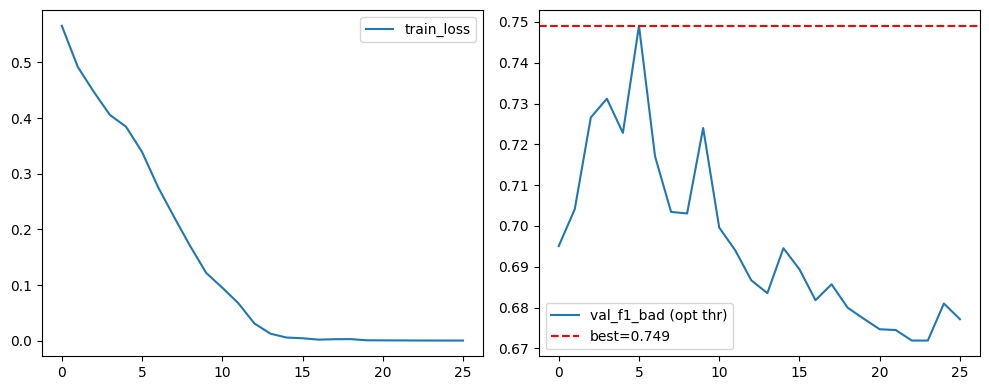

PosixPath('/Users/dk/Desktop/ВШЭ/ВКР/HSE_VKR_DetectingSpeechDefects/experiments/03_pretrained/exp_hubert_lstm/result.csv')

In [32]:
train_utils.load_best_checkpoint(model, best_ckpt, DEVICE)

print(f"Обучение головы: {train_time_sec:.1f} с | best val_f1_bad={best_f1:.4f}")

val_proba, val_true = eval_loader(val_loader)
optimal_threshold = find_optimal_threshold(val_true, val_proba)
print(f"Оптимальный порог: {optimal_threshold:.2f}")

test_proba, test_true = eval_loader(test_loader)
test_metrics = evaluate(test_true, test_proba, threshold=optimal_threshold, verbose=True)
pd.DataFrame({
    "path":    paths_test,
    "y_true":  test_true,
    "y_pred":  (test_proba >= optimal_threshold).astype(int),
    "y_proba": test_proba,
}).to_csv(exp_dir / "test_predictions.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(train_losses, label="train_loss"); axes[0].legend()
axes[1].plot(val_f1s, label="val_f1_bad (opt thr)")
axes[1].axhline(best_f1, color="r", linestyle="--", label=f"best={best_f1:.3f}"); axes[1].legend()
plt.tight_layout()
fig.savefig(exp_dir / "training_curves.png", dpi=120)
plt.show()

save_result_csv(
    exp_dir=exp_dir,
    experiment_id="exp_hubert_lstm",
    experiment_name="HuBERT (frozen) + BiLSTM (предвычисленные эмбеддинги)",
    accuracy=test_metrics["accuracy"],
    f1_macro=test_metrics["f1_macro"],
    f1_bad=test_metrics["f1_bad"],
    roc_auc=test_metrics["roc_auc"],
    precision_bad=test_metrics["precision_bad"],
    recall_bad=test_metrics["recall_bad"],
    threshold=test_metrics["threshold"],
    embed_dim=256,
    embed_dim_note="HuBERT(768)  BiLSTM(128, bidir.)  fc=Linear(256+n_letters)",
    notes=f"Предвычисленные эмбеддинги | thr={optimal_threshold:.2f} | lstm_hidden={LSTM_HIDDEN} | ckpt by val_f1_bad(opt_thr)",
    num_params=n_params,
    train_time_sec=train_time_sec,
)